# 07-epitope-databases

In [1]:
import scanpy as sc
import scirpy as ir
import numpy as np
import json
from pathlib import Path
import pandas as pd
import muon as mu
import anndata as ad
import gzip
import shutil
from concurrent.futures import ThreadPoolExecutor
import matplotlib.cm as mpl_cm
from cycler import cycler
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

DATA = Path("data")

N_SAMPLES = [
  "LN1",
  "LN2",
  "LN3",
  "LN4",
  "LN5",
  "LN6",
  "EN1",
  "EN2",
  "EN3",
  "CN1",
  "CN2",
  "RN1",
  "RN2",
  "RN3",
]

T_SAMPLES = [
  "LT1",
  "LT2",
  "LT3",
  "LT4",
  "LT5",
  "LT6",
  "ET1",
  "ET2",
  "ET3",
  "CT1",
  "CT2",
  "RT1",
  "RT2",
  "RT3",
]

B_SAMPLES = [
  "LB6",
  "RB1",
  "RB2",
  "RB3",
]

SAMPLES = N_SAMPLES + T_SAMPLES + B_SAMPLES

def sample_tissue(sample: str) -> str:
  if sample in B_SAMPLES:
    return "Blood"
  if sample in N_SAMPLES:
    return "Normal"
  if sample in T_SAMPLES:
    return "Tumor"
  raise ValueError(f"Unknown sample: {sample}")

/Users/alegator1209/micromamba/envs/pytcr/lib/python3.12/site-packages/h5py/__init__.py:36: UserWarning: h5py is running against HDF5 2.2.0 when it was built against 2.1.0, this may cause problems
  _warn(("h5py is running against HDF5 {0} when it was built against {1}, "
Matplotlib is building the font cache; this may take a moment.
/Users/alegator1209/micromamba/envs/pytcr/lib/python3.12/site-packages/muon/_core/preproc.py:32: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  if Version(scanpy.__version__) < Version("1.10"):


In [2]:
def extract_file(path: Path) -> Path:
  extracted = Path(str(path).partition(".gz")[0])

  with gzip.open(path, 'rb') as f_in:
    with open(extracted, 'wb') as f_out:
      shutil.copyfileobj(f_in, f_out)

  return extracted

def extract_mtx_data(dir: Path, prefix: str):
  extract_file(dir / f"{prefix}barcodes.tsv.gz")
  extract_file(dir / f"{prefix}genes.tsv.gz")
  extract_file(dir / f"{prefix}matrix.mtx.gz")

In [3]:
def find_prefix(dir: Path) -> str:
  matches = list(dir.glob("*barcodes.tsv.gz"))
  if len(matches) != 1:
    raise ValueError(f"Expected exactly one barcodes.tsv.gz file in {dir}, found {len(matches)}")
  return matches[0].name.removesuffix("barcodes.tsv.gz")

def read_sample(dir: Path) -> mu.MuData:
  print(f"Reading sample {dir.name}")
  prefix = find_prefix(dir)
  extract_mtx_data(dir, prefix)

  adata = sc.read_10x_mtx(dir, prefix=prefix)
  adata.var_names_make_unique()
  adata_tcr = ir.io.read_10x_vdj(dir / f"{prefix}filtered_contig_annotations.csv.gz")

  mdata = mu.MuData({'gex': adata, 'airr': adata_tcr})
  mdata['gex'].obs['sample'] = dir.name
  mdata['gex'].obs['source'] = sample_tissue(dir.name)
  mdata.update()

  return mdata

In [4]:
with ThreadPoolExecutor(max_workers=8) as executor:
  samples = list(executor.map(lambda s: read_sample(DATA / s), SAMPLES))

Reading sample LN1
Reading sample LN2
Reading sample LN3
Reading sample LN4
Reading sample LN5
Reading sample LN6
Reading sample EN1
Reading sample EN2
Reading sample EN3
Reading sample CN1
Reading sample CN2
Reading sample RN1
Reading sample RN2
Reading sample RN3
Reading sample LT1
Reading sample LT2
Reading sample LT3
Reading sample LT4
Reading sample LT5
Reading sample LT6
Reading sample ET1
Reading sample ET2
Reading sample ET3
Reading sample CT1
Reading sample CT2
Reading sample RT1
Reading sample RT2
Reading sample RT3
Reading sample LB6
Reading sample RB1
Reading sample RB2
Reading sample RB3


In [5]:
def preprocess(sample: mu.MuData) -> mu.MuData:
  sc.pp.filter_genes(sample["gex"], min_cells=10)
  sc.pp.filter_cells(sample["gex"], min_genes=100)
  return sample

def integrate(samples: list[mu.MuData]) -> mu.MuData:
  gex = ad.concat(
    {s.obs["gex:sample"].iloc[0]: s["gex"] for s in samples},
    index_unique='-',
    join='outer',
  )

  airr = ad.concat(
    {s.obs["gex:sample"].iloc[0]: s["airr"] for s in samples},
    index_unique='-',
    join='outer',
  )

  mdata = mu.MuData({'gex': gex, 'airr': airr})
  mu.pp.intersect_obs(mdata)
  mdata.update()
  return mdata

In [6]:
samples = [preprocess(s) for s in samples]
mdata = integrate(samples)
mdata

MuData object with n_obs × n_vars = 110365 × 17474
  2 modalities
    gex:	110365 × 17474
      obs:	'sample', 'source', 'n_genes'
      layers:	None
    airr:	110365 × 0
      obsm:	'airr'

In [7]:
sc.pp.normalize_total(mdata["gex"])
sc.pp.log1p(mdata["gex"])
sc.pp.highly_variable_genes(mdata["gex"], flavor="cell_ranger", n_top_genes=5000)
sc.tl.pca(mdata["gex"])
sc.pp.neighbors(mdata["gex"])
sc.tl.umap(mdata["gex"])
mdata.update()
mdata

MuData object with n_obs × n_vars = 110365 × 17474
  2 modalities
    gex:	110365 × 17474
      obs:	'sample', 'source', 'n_genes'
      var:	'highly_variable', 'means', 'dispersions', 'dispersions_norm'
      uns:	'log1p', 'hvg', 'pca', 'neighbors', 'umap'
      obsm:	'X_pca', 'X_umap'
      varm:	'PCs'
      layers:	None
      obsp:	'distances', 'connectivities'
    airr:	110365 × 0
      obsm:	'airr'

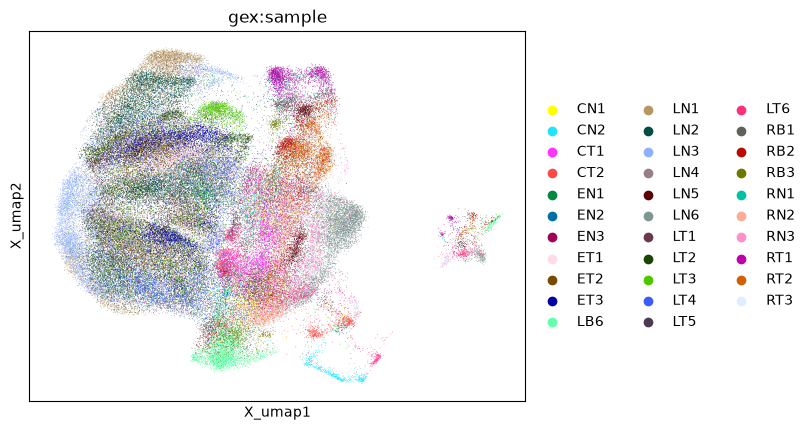

In [8]:
mu.pl.embedding(
  mdata,
  basis="gex:umap",
  color=["gex:sample"],
  ncols=3,
  wspace=0.7,
)

In [9]:
ir.pp.index_chains(mdata)
ir.tl.chain_qc(mdata)

In [10]:
mdata['airr'].obs.groupby('receptor_subtype').count()

,receptor_type,chain_pairing
receptor_subtype,,
IGH,110,110
IGH+IGK,10,10
TRA+TRB,99268,99268
TRG+TRD,1,1
ambiguous,2,2
multichain,499,499
no IR,10475,10475


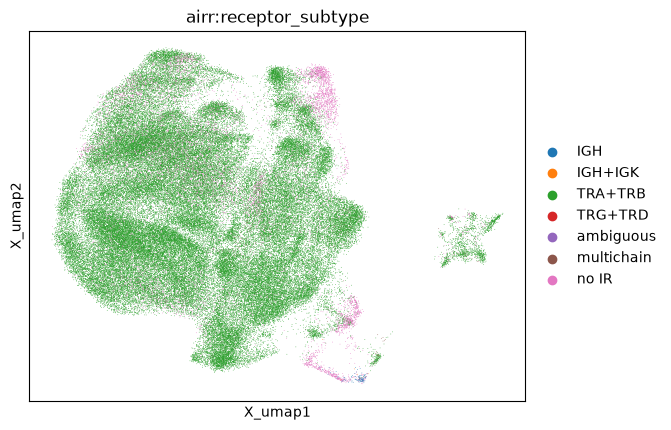

In [11]:
mu.pl.embedding(
  mdata,
  basis="gex:umap",
  color=["airr:receptor_subtype"],
  ncols=3,
  wspace=0.7,
)

In [12]:
mu.pp.filter_obs(mdata, "airr:receptor_subtype", lambda x: x == "TRA+TRB")

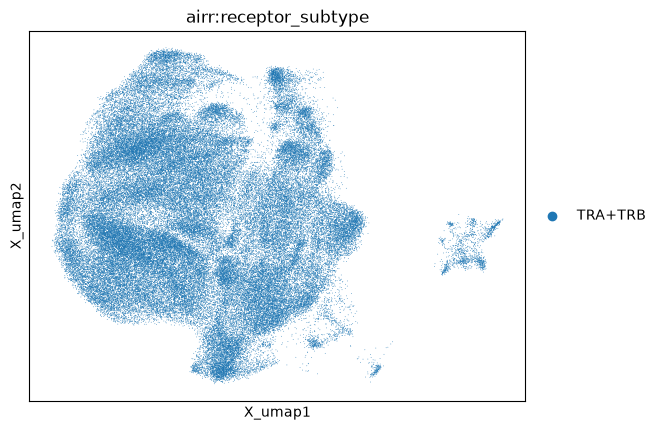

In [13]:
mu.pl.embedding(
  mdata,
  basis="gex:umap",
  color=["airr:receptor_subtype"],
  ncols=3,
  wspace=0.7,
)

In [14]:
mu.pp.filter_obs(mdata, "airr:chain_pairing", lambda x: ~np.isin(x, ["no IR", "orphan VDJ", "orphan VJ", "multichain"]))

In [15]:
mdata.obs.groupby("airr:chain_pairing").count()

,gex:sample,gex:source,gex:n_genes,airr:receptor_type,airr:receptor_subtype
airr:chain_pairing,,,,,
extra VDJ,2499,2499,2499,2499,2499
extra VJ,3402,3402,3402,3402,3402
single pair,55319,55319,55319,55319,55319
two full chains,750,750,750,750,750


In [16]:
ir.pp.ir_dist(mdata)
ir.tl.define_clonotypes(mdata, receptor_arms="all", dual_ir="primary_only")
ir.tl.clonotype_network(mdata, min_cells=3)
ir.pp.ir_dist(
    mdata,
    metric="tcrdist",
    sequence="aa",
    cutoff=15,
)
ir.tl.define_clonotype_clusters(mdata, sequence="aa", metric="tcrdist", receptor_arms="all", dual_ir="any")
ir.tl.clonotype_network(mdata, min_cells=3, sequence="aa", metric="tcrdist")

/Users/alegator1209/micromamba/envs/pytcr/lib/python3.12/site-packages/scirpy/tl/_clonotypes.py:320: DeprecationWarning: Graph.clusters() is deprecated; use Graph.connected_components() instead
  part = g.clusters(mode="weak")
/Users/alegator1209/micromamba/envs/pytcr/lib/python3.12/site-packages/scirpy/tl/_clonotypes.py:320: DeprecationWarning: Graph.clusters() is deprecated; use Graph.connected_components() instead
  part = g.clusters(mode="weak")


In [17]:
mdata.obs.groupby("gex:source", dropna=False).size()

gex:source
Blood      4146
Normal    24933
Tumor     32891
dtype: int64

In [18]:
iggytop = ir.datasets.iggytop()

In [19]:
ir.pp.ir_dist(mdata, iggytop, metric="identity", sequence="aa")

In [20]:
ir.tl.ir_query(
  mdata,
  iggytop,
  metric="identity",
  sequence="aa",
  receptor_arms="any",
  dual_ir="any",
)

ir.tl.ir_query_annotate(
  mdata,
  iggytop,
  metric="identity",
  sequence="aa",
  include_ref_cols=["antigen_species"],
  strategy="most-frequent",
)

ir.tl.ir_query_annotate_df(
  mdata,
  iggytop,
  metric="identity",
  sequence="aa",
  include_ref_cols=["antigen_species", "antigen_name"],
)

  0%|          | 0/16089 [00:00<?, ?it/s]

,antigen_species,antigen_name
AAACCTGTCTCGCATC-1-LN1,Severe acute respiratory syndrome coronavirus 2,ORF1ab
AAACCTGTCTCGCATC-1-LN1,Yellow fever virus,NS4B
AAACCTGTCTCGCATC-1-LN1,Homo sapiens,CCND1
AAACCTGTCTCGCATC-1-LN1,Cytomegalovirus,pp65
AAACCTGTCTCGCATC-1-LN1,Cytomegalovirus,pp65
...,...,...
TTGACTTTCTATCCTA-1-RB3,Rotavirus A,VP3
TTGACTTTCTATCCTA-1-RB3,Severe acute respiratory syndrome coronavirus 2,Spike glycoprotein
TTGACTTTCTATCCTA-1-RB3,Severe acute respiratory syndrome coronavirus 2,Spike glycoprotein
TTGTAGGAGGTGCACA-1-RB3,Severe acute respiratory syndrome coronavirus 2,orf1ab polyprotein


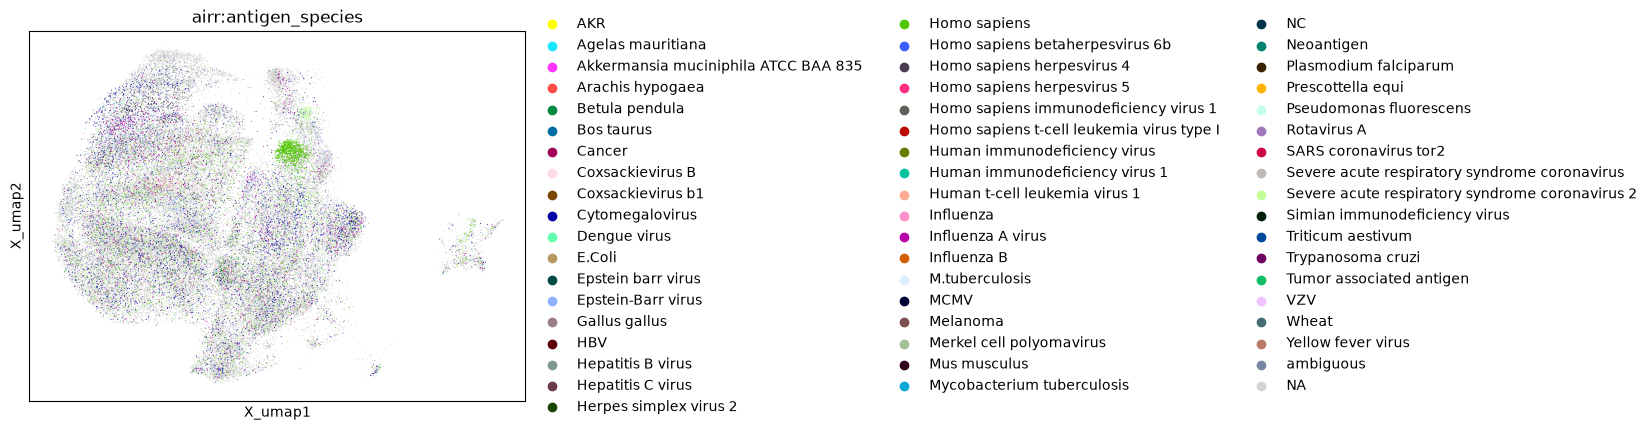

In [21]:
mu.pl.embedding(mdata, "gex:umap", color="airr:antigen_species")

In [22]:
normal_mdata = mdata[mdata.obs["gex:source"] == "Normal"].copy()
top_antigen_species_normal = normal_mdata['airr'].obs['antigen_species'].value_counts().idxmax()

print(f"Most abundant antigen species (normal tissue): {top_antigen_species_normal}")

Most abundant antigen species (normal tissue): Severe acute respiratory syndrome coronavirus 2


In [30]:
tumor_mdata = mdata[mdata.obs["gex:source"] == "Tumor"].copy()
counts = tumor_mdata['airr'].obs['antigen_species'].value_counts()
counts = counts[counts.index != "ambiguous"]
display(counts)
top_antigen_species_tumor = counts.index[1:3].to_list()

print(f"Most abundant antigen species (tumor tissue): {top_antigen_species_tumor}")

antigen_species
Severe acute respiratory syndrome coronavirus 2    1853
Homo sapiens                                       1120
Cytomegalovirus                                    1115
Influenza A virus                                   844
Epstein-Barr virus                                  680
Homo sapiens herpesvirus 4                          307
Yellow fever virus                                  123
Merkel cell polyomavirus                             92
Influenza                                            51
Homo sapiens herpesvirus 5                           42
Hepatitis C virus                                    42
Neoantigen                                           39
SARS coronavirus tor2                                32
Cancer                                               27
Severe acute respiratory syndrome coronavirus        23
Influenza B                                          20
Human immunodeficiency virus 1                       14
MCMV                            

Most abundant antigen species (tumor tissue): ['Homo sapiens', 'Cytomegalovirus']


In [24]:
blood_mdata = mdata[mdata.obs["gex:source"] == "Blood"].copy()
abundance = blood_mdata['airr'].obs['antigen_species'].value_counts()
abundance = abundance[abundance > 5]
n_blood_antigens = abundance.shape[0]

print(f"Amount of blood antigen species with more than 5 cells: {n_blood_antigens}")

Amount of blood antigen species with more than 5 cells: 8


In [31]:
output = {
  "top_antigen_species_normal": top_antigen_species_normal,
  "top_antigen_species_tumor": top_antigen_species_tumor,
  "n_blood_antigens": n_blood_antigens
}

print(json.dumps(output, indent=2))

# with open('output.json', 'w') as f:
#     json.dump(output, f, indent=2)
# print('Results saved to output.json:')

{
  "top_antigen_species_normal": "Severe acute respiratory syndrome coronavirus 2",
  "top_antigen_species_tumor": [
    "Homo sapiens",
    "Cytomegalovirus"
  ],
  "n_blood_antigens": 8
}
